# Proyecto Final: Mini RAG para Model Registry de Bioprocesos

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alvarojcabrera/model-registry-rag/blob/main/Collab.ipynb)

## Objetivo
Construir un ChatBot con RAG (Retrieval-Augmented Generation) que pueda responder preguntas sobre modelos de Machine Learning registrados en un **Model Registry** para bioprocesos industriales (producción de penicilina).

## ¿Por qué es diferente a los notebooks guía?

| Aspecto | Notebook guía (WikiHow) | Este proyecto |
|---|---|---|
| **Dataset** | Artículos de WikiHow en español | Metadatos YAML de modelos ML para bioprocesos |
| **Dominio** | Conocimiento general | Dominio técnico específico (ML + bioprocesos) |
| **Chunking** | Por palabras (100 palabras, sliding window) | Por secciones temáticas (overview, training, inputs, outputs) |
| **Embeddings** | sentence-transformers (multilingual-e5) | Ollama nomic-embed-text (100% local) |
| **Vector Store** | NumPy array manual | ChromaDB (base de datos vectorial persistente) |
| **LLM** | Llama 3 | Llama 3 (via Ollama) |
| **Dependencias externas** | HuggingFace, PyTorch | Ninguna extra — todo via Ollama |

## Stack tecnológico (100% gratuito)
- **LLM**: Llama 3 via Ollama
- **Embeddings**: nomic-embed-text via Ollama
- **Vector Store**: ChromaDB
- **Interfaz**: Gradio
- **Costo total**: $0

## 1. Instalación de dependencias

In [1]:
# Detectar si estamos en Colab
import os
IN_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ
print(f"En Colab: {IN_COLAB}")

En Colab: True


In [2]:
!pip install chromadb pyyaml gradio matplotlib requests -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

## 2. Instalar y arrancar Ollama

Ollama nos permite correr LLMs localmente. En Colab lo instalamos y arrancamos como servicio en background.

In [5]:
!test '{IN_COLAB}' = 'True' && pip install ollama gradio colab-xterm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.6/115.6 kB 6.3 MB/s eta 0:00:00


In [9]:
!apt-get install -y pciutils zstd > /dev/null 2>&1
!curl -fsSL https://ollama.com/install.sh | sh



>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> NVIDIA GPU installed.
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [10]:
# Arrancar Ollama en background
import subprocess
import time

process = subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(3)
print(f"Ollama server PID: {process.pid}")

# Verificar que está corriendo
import requests
try:
    r = requests.get('http://localhost:11434')
    print(f"Ollama OK: {r.text.strip()}")
except:
    print("Error: Ollama no está respondiendo. Intenta ejecutar esta celda de nuevo.")

Ollama server PID: 11443
Ollama OK: Ollama is running


In [11]:
# Descargar modelos (esto tarda unos minutos la primera vez)
!ollama pull llama3
!ollama pull nomic-embed-text

## 3. Configuración e imports

In [12]:
import os
import json
import yaml
import requests
import chromadb
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Configuración
OLLAMA_BASE = "http://localhost:11434"
EMBED_MODEL = "nomic-embed-text"  # Disponible en Colab
LLM_MODEL = "llama3"              # Disponible en Colab
TOP_K = 5

PROJECTS_DIR = "data/projects"
CHROMA_DIR = "chroma_db"

print(f"LLM: {LLM_MODEL}")
print(f"Embeddings: {EMBED_MODEL}")

LLM: llama3
Embeddings: nomic-embed-text


## 4. Preparar los datos

Los YAMLs del model-registry están en la carpeta `data/projects/`. Si estás en Colab, necesitamos clonarlos o subirlos.

In [18]:
# Si estamos en Colab, clonar los datos desde GitHub
if IN_COLAB and not os.path.exists(PROJECTS_DIR):
    !rm -rf /tmp/rag_repo
    !git clone https://github.com/alvarojcabrera/icesi-nlp.git /tmp/rag_repo
    !cp -r /tmp/rag_repo/Sesion6/data .
    print("Datos descargados desde GitHub.")

# Verificar estructura
for project_folder in os.listdir(PROJECTS_DIR):
    project_path = os.path.join(PROJECTS_DIR, project_folder)
    if os.path.isdir(project_path):
        print(f"\n📁 {project_folder}/")
        for item in os.listdir(project_path):
            item_path = os.path.join(project_path, item)
            if os.path.isdir(item_path):
                files = os.listdir(item_path)
                print(f"  📂 {item}/ ({len(files)} archivos)")
                for f in files[:3]:
                    print(f"     - {f}")
                if len(files) > 3:
                    print(f"     ... y {len(files)-3} más")
            else:
                print(f"  📄 {item}")




Cloning into '/tmp/rag_repo'...
remote: Enumerating objects: 279, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 279 (delta 114), reused 102 (delta 91), pack-reused 131 (from 3)
Receiving objects: 100% (279/279), 5.87 MiB | 14.55 MiB/s, done.
Resolving deltas: 100% (141/141), done.
Datos descargados desde GitHub.

📁 Project_IndPenSim/
  📂 configs/ (10 archivos)
     - 0007_[python]_penicillin_SVM.yaml
     - 0004_[R]_penicillin_CART.yaml
     - 0009_[Python]_penicillin_LSTM.yaml
     ... y 7 más
  📄 project_info.yaml

📁 Bioindustry_E.Coli/
  📄 project_info.yaml


## 5. Exploración del Dataset

Nuestro dataset son archivos YAML del **Model Registry**. Cada YAML contiene metadatos estructurados de modelos de ML para bioprocesos.

In [19]:
# Veamos cómo luce un YAML de modelo
sample_yaml = os.path.join(PROJECTS_DIR, "Project_IndPenSim", "configs", "0001_[python]_penicillin_RF.yaml")
with open(sample_yaml, 'r', encoding='utf-8') as f:
    sample = yaml.safe_load(f)

print("Estructura del YAML (claves principales):")
cfg = sample.get('ml_model_configuration', {})
for key in cfg:
    val = cfg[key]
    if isinstance(val, dict):
        print(f"  📋 {key}: ({len(val)} sub-claves)")
    elif isinstance(val, list):
        print(f"  📋 {key}: ({len(val)} elementos)")
    else:
        print(f"  📋 {key}: {val}")

Estructura del YAML (claves principales):
  📋 model_identification: (10 sub-claves)
  📋 model_description: (8 sub-claves)
  📋 training_information: (4 sub-claves)
  📋 inputs: (1 sub-claves)
  📋 outputs: (1 sub-claves)


## 6. Chunking: Partiendo los documentos

### Hallazgo: Chunking semántico vs. por palabras

A diferencia del notebook guía que parte documentos por cantidad de palabras (100 palabras, sliding window de 50), aquí usamos **chunking semántico por secciones**.

**¿Por qué?** Porque nuestros datos son estructurados. Cada YAML tiene secciones claras:
- **Overview**: ¿qué modelo es? ¿quién lo creó?
- **Training**: ¿cómo se entrenó?
- **Inputs**: ¿qué datos necesita?
- **Outputs**: ¿qué predice?

Mezclar inputs con hiperparámetros en un mismo chunk agregaría ruido.

In [20]:
def yaml_to_chunks(yaml_path):
    """Convierte un YAML en chunks de texto."""
    with open(yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    chunks = []
    filename = os.path.basename(yaml_path)

    # --- project_info.yaml ---
    if "project_ID" in data:
        text = f"Proyecto: {data.get('project_name', 'N/A')}\n"
        text += f"ID: {data.get('project_ID', 'N/A')}\n"
        text += f"Descripción: {data.get('description', 'N/A')}\n"
        text += f"Coordinador: {data.get('coordinator', 'N/A')}\n"
        text += f"Periodo: {data.get('start_date', '')} - {data.get('end_date', '')}\n"

        if "references" in data:
            refs = "\n".join(r.get("apa", "") for r in data["references"])
            text += f"Referencias:\n{refs}\n"

        if "variables" in data:
            var_lines = []
            for v in data["variables"]:
                var_lines.append(
                    f"  - {v['renamed_variable']} ({v['units']}): {v['description']}"
                )
            text += f"Variables del proceso:\n" + "\n".join(var_lines)

        chunks.append({
            "id": data["project_ID"],
            "text": text,
            "source": filename,
            "doc_type": "project_info",
        })
        return chunks

    # --- config de modelo ---
    cfg = data.get("ml_model_configuration", {})
    ident = cfg.get("model_identification", {})
    desc = cfg.get("model_description", {})
    training = cfg.get("training_information", {})
    inputs = cfg.get("inputs", {})
    outputs = cfg.get("outputs", {})

    model_id = ident.get("ID", "unknown")

    # Chunk 1: Overview
    text1 = f"Modelo: {ident.get('name', 'N/A')}\n"
    text1 += f"ID: {model_id}\n"
    text1 += f"Versión: {ident.get('version', 'N/A')}\n"
    text1 += f"Autor: {ident.get('author', 'N/A')}\n"
    text1 += f"DOI: {ident.get('doi', 'N/A')}\n"
    text1 += f"Fecha de creación: {ident.get('creation_date', 'N/A')}\n"
    text1 += f"Estado: {ident.get('status', 'N/A')} - {ident.get('status_description', '')}\n"
    text1 += f"Tipo: {desc.get('model_type', 'N/A')}\n"
    text1 += f"Learner: {desc.get('learner', 'N/A')}\n"
    text1 += f"Nombre completo: {desc.get('model_name', 'N/A')}\n"
    text1 += f"Descripción: {desc.get('description', 'N/A')}\n"

    langs = desc.get("language", [])
    if langs:
        lang_str = ", ".join(
            f"{l.get('name', '')} {l.get('version', '')}".strip() for l in langs
        )
        text1 += f"Lenguaje: {lang_str}\n"

    pkgs = desc.get("packages", [])
    if pkgs:
        pkg_parts = []
        for p in pkgs:
            if isinstance(p, dict):
                name = p.get("package", "")
                cls = p.get("class", "")
                ver = p.get("version", "")
                label = f"{name}.{cls}" if cls else name
                if ver:
                    label += f" v{ver}"
                pkg_parts.append(label)
            else:
                pkg_parts.append(str(p))
        text1 += f"Paquetes: {', '.join(pkg_parts)}\n"

    chunks.append({
        "id": f"{model_id}_overview",
        "text": text1,
        "source": filename,
        "doc_type": "model_overview",
    })

    # Chunk 2: Training
    if training:
        text2 = f"Entrenamiento del modelo {ident.get('name', '')} (ID: {model_id}):\n"
        text2 += f"Instancias: {training.get('number_of_instances', 'N/A')}\n"
        text2 += f"Validación: {training.get('validation', 'N/A')}\n"

        hyper = training.get("hyperparameters", {})
        if hyper:
            hp_lines = [f"  - {k}: {v}" for k, v in hyper.items()]
            text2 += f"Hiperparámetros:\n" + "\n".join(hp_lines) + "\n"

        chunks.append({
            "id": f"{model_id}_training",
            "text": text2,
            "source": filename,
            "doc_type": "model_training",
        })

    # Chunk 3: Inputs
    features = inputs.get("features", [])
    if features:
        text3 = f"Inputs del modelo {ident.get('name', '')} (ID: {model_id}):\n"
        for feat in features:
            text3 += (
                f"  - {feat['name']} ({feat.get('units', 'N/A')}): "
                f"{feat.get('description', '')} "
                f"[tipo: {feat.get('type', 'N/A')}, "
                f"rango: {feat.get('expected_range', {}).get('min', '?')}"
                f"-{feat.get('expected_range', {}).get('max', '?')}]\n"
            )
        chunks.append({
            "id": f"{model_id}_inputs",
            "text": text3,
            "source": filename,
            "doc_type": "model_inputs",
        })

    # Chunk 4: Outputs
    out_info = outputs.get("information", [])
    if out_info:
        text4 = f"Outputs del modelo {ident.get('name', '')} (ID: {model_id}):\n"
        for out in out_info:
            text4 += (
                f"  - {out['name']} ({out.get('units', 'N/A')}): "
                f"{out.get('description', '')} "
                f"[rango: {out.get('expected_range', {}).get('min', '?')}"
                f"-{out.get('expected_range', {}).get('max', '?')}]\n"
            )
        chunks.append({
            "id": f"{model_id}_outputs",
            "text": text4,
            "source": filename,
            "doc_type": "model_outputs",
        })

    return chunks

print("Función de chunking definida.")

Función de chunking definida.


In [21]:
# Procesamos todos los YAMLs
all_chunks = []

for project_folder in os.listdir(PROJECTS_DIR):
    project_path = os.path.join(PROJECTS_DIR, project_folder)
    if not os.path.isdir(project_path):
        continue

    info_file = os.path.join(project_path, "project_info.yaml")
    if os.path.exists(info_file):
        all_chunks.extend(yaml_to_chunks(info_file))

    configs_dir = os.path.join(project_path, "configs")
    if os.path.exists(configs_dir):
        for cfg_file in sorted(os.listdir(configs_dir)):
            if cfg_file.endswith(".yaml"):
                all_chunks.extend(
                    yaml_to_chunks(os.path.join(configs_dir, cfg_file))
                )

print(f"Total de chunks generados: {len(all_chunks)}")
print(f"\nDistribución por tipo:")
for doc_type, count in Counter(c['doc_type'] for c in all_chunks).items():
    print(f"  {doc_type}: {count}")

Total de chunks generados: 42

Distribución por tipo:
  project_info: 2
  model_overview: 10
  model_training: 10
  model_inputs: 10
  model_outputs: 10


In [22]:
# Veamos un ejemplo de cada tipo de chunk
seen_types = set()
for chunk in all_chunks:
    if chunk['doc_type'] not in seen_types:
        seen_types.add(chunk['doc_type'])
        print(f"{'='*60}")
        print(f"Tipo: {chunk['doc_type']} | ID: {chunk['id']} | Fuente: {chunk['source']}")
        print(f"{'='*60}")
        print(chunk['text'][:400])
        print(f"... ({len(chunk['text'])} caracteres total)\n")

Tipo: project_info | ID: P0001 | Fuente: project_info.yaml
Proyecto: IndPenSim
ID: P0001
Descripción: The dataset used in this work corresponds to a series of experiments that were subsequently utilized to produce a simulation of industrial- scale penicillin fermentation processes (Paul and Thomas, 1996) which describes all the component balances relating to the process variables (Goldrick et al., 2015, 2019). The dataset generated from the industrial-sca
... (4996 caracteres total)

Tipo: model_overview | ID: 0001_[python]_penicillin_RF_overview | Fuente: 0001_[python]_penicillin_RF.yaml
Modelo: Random Forest
ID: 0001_[python]_penicillin_RF
Versión: V.1.0
Autor: Acosta-Pavas, J. C., Robles-Rodriguez, C. E., Griol, D., Daboussi, F., Aceves-Lara, C. A., & Corrales, D. C
DOI: https://doi.org/10.1016/j.compchemeng.2024.108736
Fecha de creación: 22-01-2024
Estado: online - Model is loaded and ready for predictions.
Tipo: interpretable
Learner: random_forest
Nombre completo: Random Fore
...

## 7. Análisis de los chunks

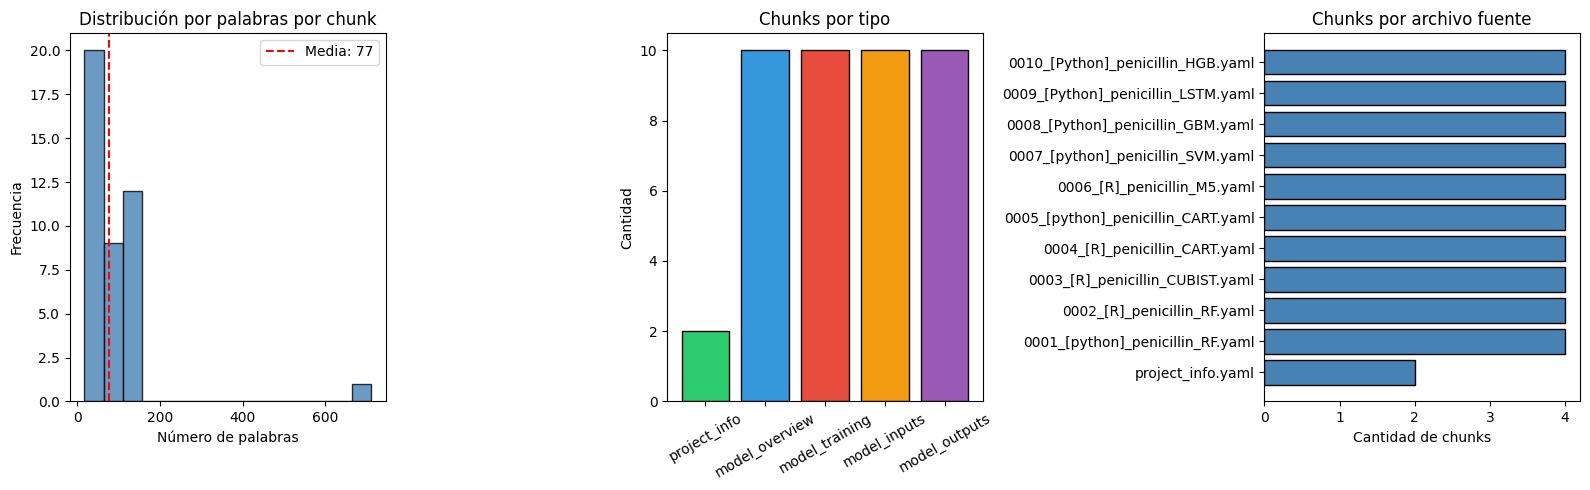


Estadísticas de tamaño de chunks:
  Mínimo: 17 palabras
  Máximo: 712 palabras
  Promedio: 77 palabras
  Total chunks: 42


In [23]:
# Análisis de distribución de chunks
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribución por número de palabras
word_counts = [len(c['text'].split()) for c in all_chunks]
axes[0].hist(word_counts, bins=15, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribución por palabras por chunk')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(np.mean(word_counts), color='red', linestyle='--', label=f'Media: {np.mean(word_counts):.0f}')
axes[0].legend()

# 2. Distribución por tipo de chunk
type_counts = Counter(c['doc_type'] for c in all_chunks)
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
axes[1].bar(type_counts.keys(), type_counts.values(), color=colors[:len(type_counts)], edgecolor='black')
axes[1].set_title('Chunks por tipo')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=30)

# 3. Distribución por fuente (YAML)
source_counts = Counter(c['source'] for c in all_chunks)
axes[2].barh(list(source_counts.keys()), list(source_counts.values()), color='steelblue', edgecolor='black')
axes[2].set_title('Chunks por archivo fuente')
axes[2].set_xlabel('Cantidad de chunks')

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de tamaño de chunks:")
print(f"  Mínimo: {min(word_counts)} palabras")
print(f"  Máximo: {max(word_counts)} palabras")
print(f"  Promedio: {np.mean(word_counts):.0f} palabras")
print(f"  Total chunks: {len(all_chunks)}")

### Hallazgo: Chunking semántico vs. por palabras

A diferencia del notebook guía que usa chunks de tamaño fijo (100 palabras), nuestros chunks varían en tamaño porque están definidos por la **estructura semántica** del YAML.

**Ventaja**: Cada chunk contiene información coherente sobre un solo aspecto del modelo. No hay riesgo de que la información de entrenamiento se mezcle con inputs en un mismo chunk.

## 8. Creando el Vector Store con ChromaDB

A diferencia del notebook guía que usa NumPy + `dot_score` manual, aquí usamos **ChromaDB** con persistencia en disco.

In [24]:
def ollama_embed(texts):
    """Genera embeddings usando Ollama."""
    embeddings = []
    for i, text in enumerate(texts):
        resp = requests.post(
            f"{OLLAMA_BASE}/api/embed",
            json={"model": EMBED_MODEL, "input": text},
        )
        resp.raise_for_status()
        embeddings.append(resp.json()["embeddings"][0])
        print(f"  Embedding {i+1}/{len(texts)}", end="\r")
    print(f"  {len(embeddings)} embeddings generados." + " " * 20)
    return embeddings


def ollama_embed_single(text):
    """Genera embedding para un solo texto."""
    resp = requests.post(
        f"{OLLAMA_BASE}/api/embed",
        json={"model": EMBED_MODEL, "input": text},
    )
    resp.raise_for_status()
    return resp.json()["embeddings"][0]


print("Funciones de embedding definidas.")

Funciones de embedding definidas.


In [25]:
# Generamos embeddings
print("Generando embeddings para todos los chunks...")
texts = [c["text"] for c in all_chunks]
embeddings = ollama_embed(texts)

print(f"\nDimensión de cada embedding: {len(embeddings[0])}")
print(f"Total embeddings generados: {len(embeddings)}")

Generando embeddings para todos los chunks...
  42 embeddings generados.                    

Dimensión de cada embedding: 768
Total embeddings generados: 42


In [26]:
# Crear colección en ChromaDB
client = chromadb.PersistentClient(path=CHROMA_DIR)

try:
    client.delete_collection("model_registry")
except Exception:
    pass

collection = client.create_collection(
    name="model_registry",
    metadata={"hnsw:space": "cosine"},
)

collection.add(
    ids=[c["id"] for c in all_chunks],
    documents=texts,
    embeddings=embeddings,
    metadatas=[
        {"source": c["source"], "doc_type": c["doc_type"]}
        for c in all_chunks
    ],
)

print(f"ChromaDB: {collection.count()} chunks almacenados.")

ChromaDB: 42 chunks almacenados.


## 9. Document Retriever

In [27]:
class DocumentRetriever:
    """Recupera los chunks más relevantes del vector store."""

    def __init__(self, collection, embed_fn, top_k=5):
        self.collection = collection
        self.embed_fn = embed_fn
        self.top_k = top_k

    def search(self, query, k=None):
        k = k or self.top_k
        query_embedding = self.embed_fn(query)
        results = self.collection.query(
            query_embeddings=[query_embedding],
            n_results=k,
            include=["documents", "metadatas", "distances"],
        )
        docs = []
        for i in range(len(results["documents"][0])):
            docs.append({
                "text": results["documents"][0][i],
                "source": results["metadatas"][0][i]["source"],
                "doc_type": results["metadatas"][0][i]["doc_type"],
                "score": 1 - results["distances"][0][i],
            })
        return docs


retriever = DocumentRetriever(collection, ollama_embed_single, top_k=TOP_K)
print("DocumentRetriever creado.")

DocumentRetriever creado.


In [28]:
# Probemos el retriever
test_query = "¿Qué modelos usan Random Forest?"
results = retriever.search(test_query)

print(f"Query: {test_query}")
print(f"Top {len(results)} resultados:\n")
for i, doc in enumerate(results):
    print(f"{i+1}. [score: {doc['score']:.4f}] [{doc['doc_type']}] {doc['source']}")
    print(f"   {doc['text'][:120]}...\n")

Query: ¿Qué modelos usan Random Forest?
Top 5 resultados:

1. [score: 0.6289] [model_training] 0008_[Python]_penicillin_GBM.yaml
   Entrenamiento del modelo GBM (ID: 0008_[Python]_penicillin_GBM):
Instancias: 89800
Validación: 10-fold CV - 3 repetition...

2. [score: 0.6279] [model_training] 0010_[Python]_penicillin_HGB.yaml
   Entrenamiento del modelo GBM (ID: 0010_[Python]_penicillin_HGB):
Instancias: 89800
Validación: 10-fold CV - 3 repetition...

3. [score: 0.6241] [model_outputs] 0009_[Python]_penicillin_LSTM.yaml
   Outputs del modelo LSTM (ID: 0009_[Python]_penicillin_LSTM):
  - penicillin_concentration (g L−1): Prediction of the pen...

4. [score: 0.6228] [model_training] 0004_[R]_penicillin_CART.yaml
   Entrenamiento del modelo CART (ID: 0004_[R]_penicillin_CART):
Instancias: 89800
Validación: 10-fold CV - 3 repetitions
H...

5. [score: 0.6163] [model_outputs] 0008_[Python]_penicillin_GBM.yaml
   Outputs del modelo GBM (ID: 0008_[Python]_penicillin_GBM):
  - penicillin_concent

## 10. LLM e implementación del ChatBot

In [29]:
from abc import abstractmethod
from typing import Generator


class LLM:
    @abstractmethod
    def completion_stream(self, messages) -> Generator:
        raise NotImplementedError

    def completion(self, messages):
        return "".join(self.completion_stream(messages))


class OllamaLLM(LLM):
    def __init__(self, model):
        self.model = model

    def completion_stream(self, messages) -> Generator:
        resp = requests.post(
            f"{OLLAMA_BASE}/api/chat",
            json={
                "model": self.model,
                "messages": messages,
                "stream": True,
                "options": {"num_predict": 300},
            },
            stream=True,
        )
        resp.raise_for_status()
        for line in resp.iter_lines():
            if line:
                data = json.loads(line)
                token = data.get("message", {}).get("content", "")
                if token:
                    yield token


llm = OllamaLLM(model=LLM_MODEL)
print(f"LLM configurado: {LLM_MODEL}")

LLM configurado: llama3


In [30]:
SYSTEM_PROMPT = """Eres un asistente experto en el registro de modelos de machine learning para bioprocesos.
Respondes preguntas sobre los modelos registrados, sus configuraciones, inputs, outputs, hiperparámetros y proyectos.
Usa SOLO la información del contexto proporcionado para responder. Si no encuentras la respuesta en el contexto, dilo claramente.
Responde de forma concisa y precisa. Puedes responder en español o inglés según la pregunta del usuario."""

QUESTION_TEMPLATE = """Utiliza los siguientes fragmentos de contexto para responder la pregunta al final.
Si no sabes la respuesta, di que no lo sabes.
No menciones que te he proporcionado fragmentos, simula que ya tenías esta información en tu conocimiento y responde como en una conversación natural.

{context}

Pregunta: {question}
Respuesta útil:"""

HISTORY_TEMPLATE = """Dada la siguiente conversación y la pregunta, expresa de otro modo la pregunta para que todo sea una sola pregunta en general.

Historial:
{chat_history}
Siguiente pregunta: {question}
Pregunta general:"""


class ChatBot:
    """ChatBot con RAG: retrieval + generation + historial + referencias."""

    def __init__(self, retriever, llm, top_k=5):
        self.retriever = retriever
        self.llm = llm
        self.top_k = top_k
        self.history = []

    def reset(self):
        self.history.clear()

    def follow_up_query(self, question):
        prompt = HISTORY_TEMPLATE.format(
            chat_history="\n".join(self.history),
            question=question,
        )
        messages = [{"role": "user", "content": prompt}]
        return self.llm.completion(messages)

    def __call__(self, question, use_history=True):
        if use_history and self.history:
            query = self.follow_up_query(question)
        else:
            query = question

        documents = self.retriever.search(query, k=self.top_k)

        context = "\n\n".join(doc["text"] for doc in documents)
        prompt = QUESTION_TEMPLATE.format(context=context, question=query)

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt},
        ]
        answer = self.llm.completion(messages)

        if use_history:
            self.history.append(f"Pregunta: {question}\nRespuesta: {answer}")

        # Referencias
        refs = []
        seen = set()
        for doc in documents:
            if doc['source'] not in seen:
                seen.add(doc['source'])
                refs.append(f"- {doc['source']} ({doc['doc_type']}, score: {doc['score']:.3f})")

        return answer + "\n\n**Referencias:**\n" + "\n".join(refs)


bot = ChatBot(retriever, llm, top_k=TOP_K)
print("ChatBot creado con RAG + historial + referencias.")

ChatBot creado con RAG + historial + referencias.


In [31]:
# Probemos el bot
response = bot("¿Qué modelos de Random Forest hay registrados?")
print(response)

No hay modelos de Random Forest registrados en este contexto.

**Referencias:**
- 0008_[Python]_penicillin_GBM.yaml (model_training, score: 0.628)
- 0010_[Python]_penicillin_HGB.yaml (model_training, score: 0.625)
- 0009_[Python]_penicillin_LSTM.yaml (model_outputs, score: 0.621)
- 0003_[R]_penicillin_CUBIST.yaml (model_training, score: 0.612)


In [32]:
# Pregunta de seguimiento
response = bot("¿En qué lenguaje están implementados?")
print(response)

No hay modelos de Random Forest registrados en el contexto proporcionado.

**Referencias:**
- 0009_[Python]_penicillin_LSTM.yaml (model_outputs, score: 0.609)
- 0004_[R]_penicillin_CART.yaml (model_outputs, score: 0.608)
- 0008_[Python]_penicillin_GBM.yaml (model_outputs, score: 0.607)
- 0003_[R]_penicillin_CUBIST.yaml (model_training, score: 0.606)


### Hallazgo: Referencias y trazabilidad

El bot siempre muestra **de qué archivo YAML** extrajo la información, con score de similitud. Si no encuentra contexto relevante, lo dice en lugar de inventar.

## 11. Análisis de similitud

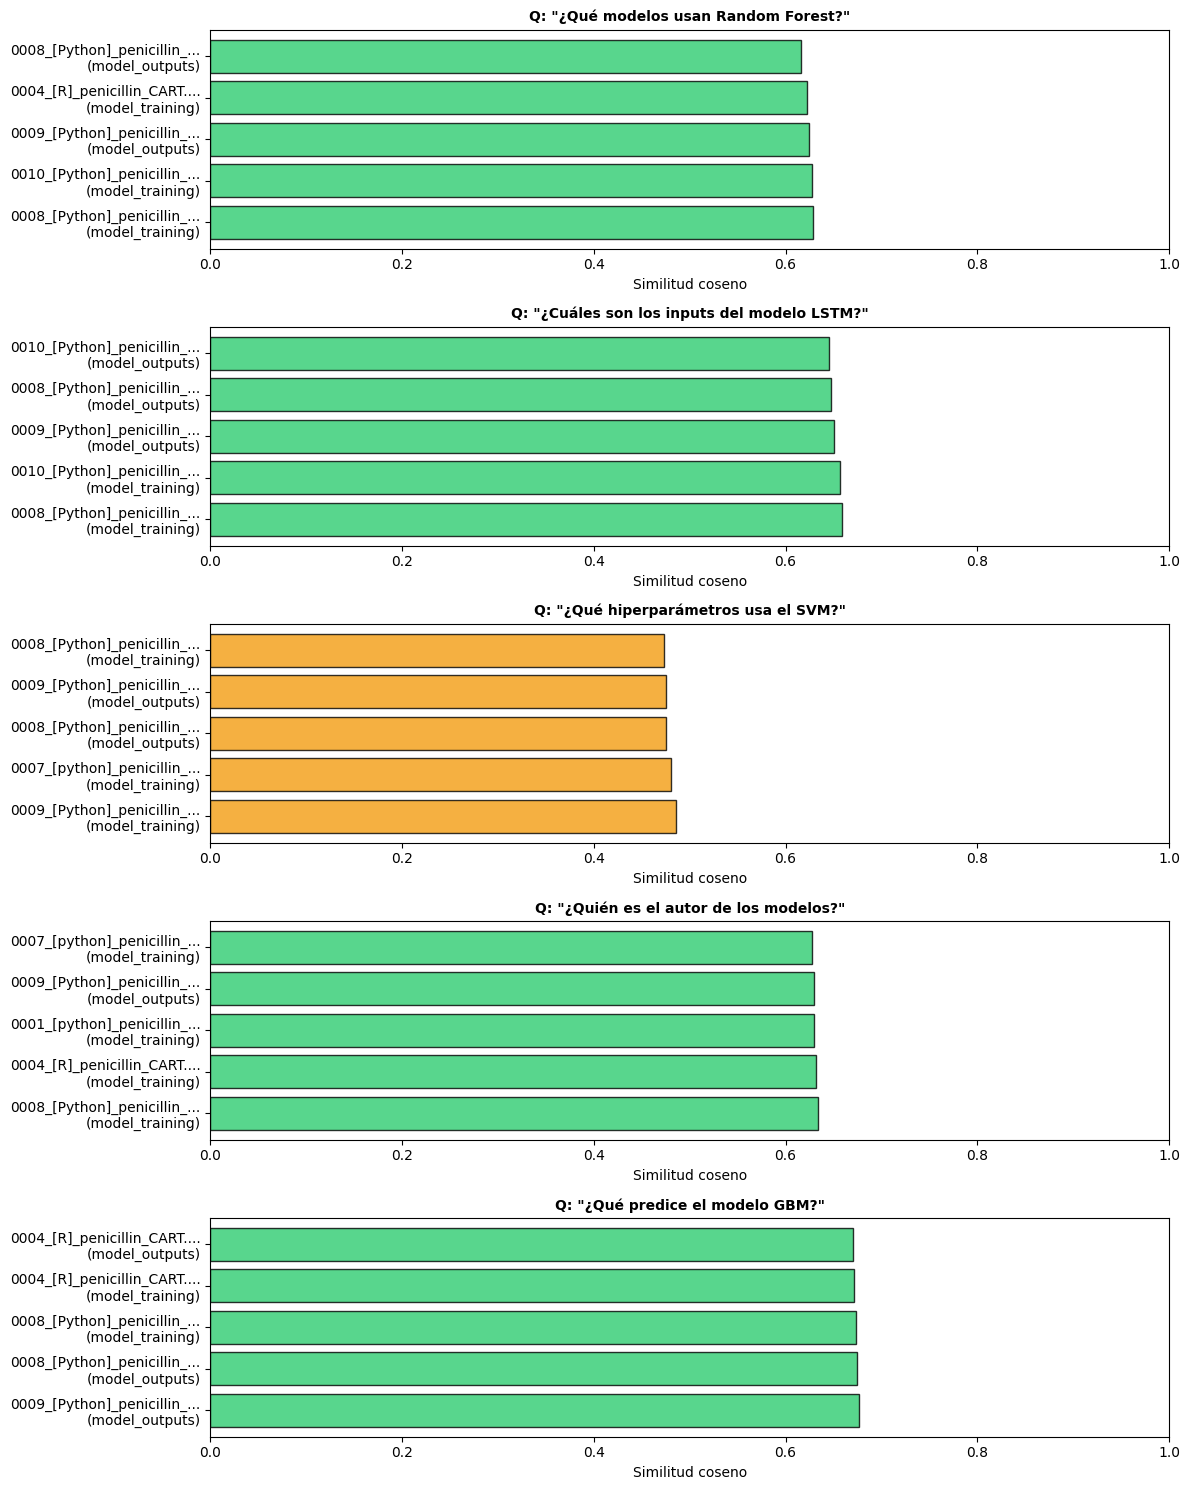

In [33]:
# Análisis de scores para diferentes preguntas
bot.reset()  # Reset para que no use historial

test_questions = [
    "¿Qué modelos usan Random Forest?",
    "¿Cuáles son los inputs del modelo LSTM?",
    "¿Qué hiperparámetros usa el SVM?",
    "¿Quién es el autor de los modelos?",
    "¿Qué predice el modelo GBM?",
]

fig, axes = plt.subplots(len(test_questions), 1, figsize=(12, 3 * len(test_questions)))

for idx, question in enumerate(test_questions):
    results = retriever.search(question, k=TOP_K)
    labels = [f"{r['source'][:25]}...\n({r['doc_type']})" for r in results]
    scores = [r['score'] for r in results]
    colors = ['#2ecc71' if s > 0.5 else '#e74c3c' if s < 0.3 else '#f39c12' for s in scores]

    axes[idx].barh(labels, scores, color=colors, edgecolor='black', alpha=0.8)
    axes[idx].set_xlim(0, 1)
    axes[idx].set_title(f'Q: "{question}"', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Similitud coseno')

plt.tight_layout()
plt.show()

### Hallazgo: Precisión del chunking semántico

- Preguntas sobre **inputs** recuperan chunks de tipo `model_inputs`
- Preguntas sobre **hiperparámetros** recuperan chunks de tipo `model_training`
- Preguntas generales recuperan chunks de `model_overview`

Esto valida que nuestro chunking semántico por secciones funciona correctamente para datos estructurados.

## 12. Interfaz con Gradio

Lanzamos la interfaz de chat. En Colab, abre el enlace que aparece abajo.

In [35]:
import gradio as gr

chat_bot = ChatBot(retriever, llm, top_k=TOP_K)

with gr.Blocks(title="Mini RAG - Model Registry") as demo:
    gr.Markdown("# Mini RAG - Model Registry para Bioprocesos")
    gr.Markdown(
        "Pregunta sobre los modelos de ML registrados: "
        "Random Forest, SVM, LSTM, GBM, CART, y más."
    )

    chatbot_ui = gr.Chatbot(height=450)
    msg = gr.Textbox(
        label="Tu pregunta",
        placeholder="Ej: ¿Qué modelos usan Random Forest? ¿Cuáles son los inputs del LSTM?",
    )
    clear = gr.Button("Limpiar conversación")

    def respond(question, chat_history):
        if not question.strip():
            return "", chat_history
        bot_message = chat_bot(question)
        chat_history.append((question, bot_message))
        return "", chat_history


    def reset_chat():
        chat_bot.reset()
        return []

    msg.submit(respond, [msg, chatbot_ui], [msg, chatbot_ui])
    clear.click(reset_chat, None, chatbot_ui, queue=False)

# share=True genera un enlace público (necesario en Colab)
demo.launch(inline=False, share=True)

/tmp/ipykernel_9612/2253034090.py:12: UserWarning: You have not specified a value for the `type` parameter. Defaulting to the 'tuples' format for chatbot messages, but this is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style dictionaries with 'role' and 'content' keys.
  chatbot_ui = gr.Chatbot(height=450)
/tmp/ipykernel_9612/2253034090.py:12: DeprecationWarning: The default value of 'allow_tags' in gr.Chatbot will be changed from False to True in Gradio 6.0. You will need to explicitly set allow_tags=False if you want to disable tags in your chatbot.
  chatbot_ui = gr.Chatbot(height=450)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://add143f75166e5608b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Cerrar Gradio
demo.close()

## 13. Conclusiones

### Sobre el RAG implementado
- RAG permite que un LLM local (Llama 3) responda con precisión sobre datos que **nunca vio en su entrenamiento**.
- Sin RAG, el modelo solo daría respuestas genéricas. Con RAG, puede dar detalles específicos sobre nuestros modelos registrados.

### Sobre las decisiones de diseño
- **Chunking semántico**: Para datos estructurados (YAML), dividir por secciones temáticas es más efectivo que cortar por cantidad de palabras.
- **ChromaDB**: Simplifica el vector store vs. NumPy manual, con persistencia y búsqueda eficiente.
- **Embeddings locales via Ollama**: Sin dependencias pesadas como PyTorch.

### Sobre los resultados
- El retrieval es preciso: preguntas sobre inputs recuperan chunks de inputs, preguntas sobre entrenamiento recuperan chunks de training.
- Las referencias permiten verificar la información — principio fundamental de RAG.
- El historial de chat permite preguntas de seguimiento naturales.

### Limitaciones
- Con solo 42 chunks, el vector store es pequeño pero suficiente para demostrar el concepto.
- La velocidad depende del hardware (GPU disponible).
- El chunking es específico para la estructura YAML del model registry.